# Ejercicio: simular y visualizar PAS

Objetivo final: completar un cuaderno como este para generar todas las imágenes del PAS de las diapositivas, subirlo a vuestro perfil de GitHub, y compartirlo conmigo. (Para final de la semana que viene, fecha a concretar).

Sobre el uso de IA generativa / LLMs:
* Se os anima a usarla para desatascaros en pasos pequeños y muy concretos (que te explique cómo hacer la media por filas de una matriz; que te explique cómo funciona cierta función que el profesor ha mencionado etc.).
* Pero no tiene sentido usarla para pasos excesivamente grandes en los que perdéis el control de qué se está haciendo (por ejemplo, decirle que te genere las figuras directamente).
* El verdadero objetivo final es entender el proceso, desarrollar habilidades de planificación, y asimilar las estructuras de pensamiento matemático-computacional subyacentes. Estáis en etapa formativa, no en etapa productiva.
* Como posible control, yo podré convocaros en clase o tutoría para que me expliquéis cómo funciona vuestro código.
* Pero, al fin y al cabo, lo que más está en juego es vuestra formación: adquirir valor añadido (ser capaz de desarrollar unas estructuras mentales que os permitan resolver problemas complejos en el futuro, problemas que quizás sean diferentes a los que hay hoy día), o ser una pieza de poco valor añadido y fácilmente sustituible (un “usuario de IA”).

Se recomienda que avancéis de aquí al lunes. Probablemente le dediquemos lunes y martes, y ya después pasemos a otra cosa. Y tendréis que entregarlo a final de semana (fecha a concretar).

Si escribís sobre este notebook que os comparto, vuestros cambios no se guardarán (porque solo tenéis permisos de lectura). Tendréis que crear una copia vuestra ("Archivo > Guardar una copia en Drive").

Alumno: Mario Líndez Martínez

---------------------------------------------------------------

In [39]:
import numpy as np
from matplotlib import pyplot as plt

## El núcleo: implementar una función para simular el PAS

Define una función `simular_PAS` que reciba tres argumentos:
* p: este es el parámetro principal del PAS. Es la probabilidad de tomar el valor 1 en cada paso (y la probabilidad de tomar el -1 sería $1-p$). Es un valor entre 0 y 1.
* n: el número de pasos a simular para cada trayectoria. Un número natural.
* reps: el número de trayectorias a simular. Un número natural.

La función debe devolver un array de numpy con dimensionalidad `(reps, n)`, que contenga los valores del PAS en cada paso para cada trayectoria.  

Esqueleto de la función a construir (a completar por vosotros):

In [40]:
def simular_PAS(p, n, reps=1):
    # Input:
    # p: Probabilidad de tomar el valor 1 en cada paso
    # n: Numero de pasos a simular en cada trayectoria
    # reps: Numero de trayectorias a simular
    # Output:
    # output: Matriz de shape (reps, n) que representa al PAS. La primera
    #         componente nos permite seleccionar la trayectoria y el segundo
    #         el paso

    # Usamos np.random.choice estableciendo como posibles valores 1 y -1 con
    # probabilidades p y (1-p) respectivamente
    steps = np.random.choice([1, -1], size=(reps, n), p=[p, 1-p])

    # Calculamos la suma acumulada de cada paso con np.cumsum que hace exactamente
    # esto. Documentacion: https://numpy.org/doc/stable/reference/generated/numpy.cumsum.html
    output = np.cumsum(steps, axis=1)


    return output  # Shape: (reps, n)

Primero piensa durante un rato cómo lo harías, e intenta completar la función. Si te quedas atrancado/a, puedes mirar la pista de abajo. **Importante**: lo fundamental de la frase anterior es "*si te quedas atrancado/a*", es decir, debes pensarlo un rato por tu cuenta. De lo contrario, si vas directo a la solución, no se produce ningún aprendizaje y no te sirve de nada.

----------------------------------------

Pista:

En principio, uno podría pensar en incluir dos bucles for:
* uno para iterar sobre las diferentes trayectorias que queremos generar (`reps`),
* otro para iterar sobre los diferentes pasos dentro de cada trayectoria (`n`).

Puedes eliminar ambos bucles construyendo un array de numpy de shape `(reps, n)` que, en cada posición, contenga un $1$ con probabilidad $p$ (y $-1$ con probabilidad $1-p$). Para esto, piensa en usar `np.random.rand` o `np.random.choice`.

Y trabajar ahora con ese array usando herramientas de numpy (piensa qué necesitas hacer con ese array, y busca en internet/LLM herramientas de numpy que hagan eso).


## Visualización 1: diferentes trayectorias del PAS (sin media ni desviación típica teóricas)

Escribir código para crear las imágenes de las diapositivas 16 ($p=0.5$), 17 ($p=0.6$) y 18 ($p=0.4$) del tema 1.

---

Crearemos una función auxiliar para ayudarnos a graficar cada PAS

In [41]:
def graficar_PAS(pas, texto="Proceso Aleatorio Simple (PAS)"):
    """
    Grafica una o varias trayectorias de un PAS.

    Parámetros:
    pas : Matriz de shape=(reps, n), donde reps es el numero de trayectorias y
          n el numero de pasos, devuelta por simular_PAS.
    texto : Título del gráfico.
    """

    reps, n = pas.shape

    # Creamos n puntos equiespaciados (0, 1, 2, 3, ..., n)
    x = np.arange(n)

    # Establecemos el tamaño de la figura
    plt.figure(figsize=(10, 6))

    # Pintamos cada trayectoria
    for i in range(reps):
        plt.plot(x, pas[i], label=f"Trayectoria {i+1}")

    plt.title(texto)
    plt.xlabel("$t$")
    plt.ylabel("$X_t$")
    plt.grid(True, ls='--', alpha=0.5)

    plt.show()

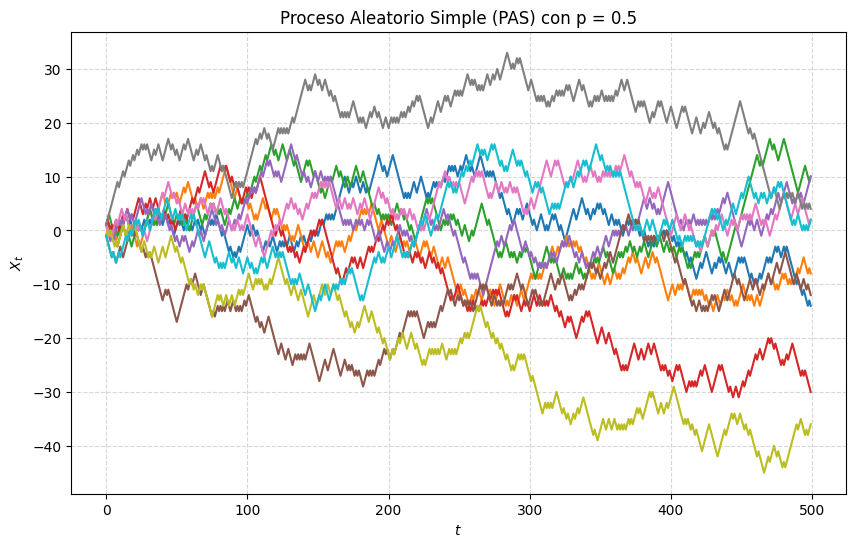

In [42]:
pas1 = simular_PAS(p=0.5, n=500, reps=10)
graficar_PAS(pas1, "Proceso Aleatorio Simple (PAS) con p = 0.5")

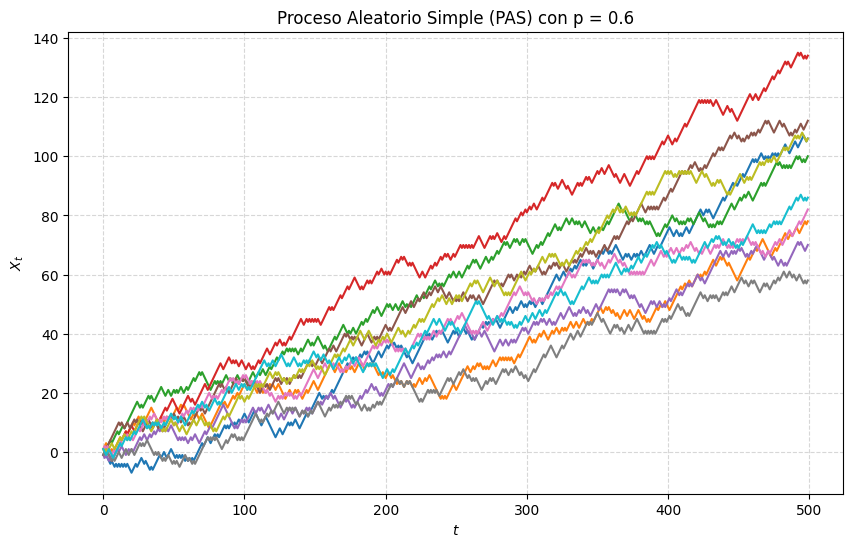

In [43]:
pas2 = simular_PAS(p=0.6, n=500, reps=10)
graficar_PAS(pas2, "Proceso Aleatorio Simple (PAS) con p = 0.6")

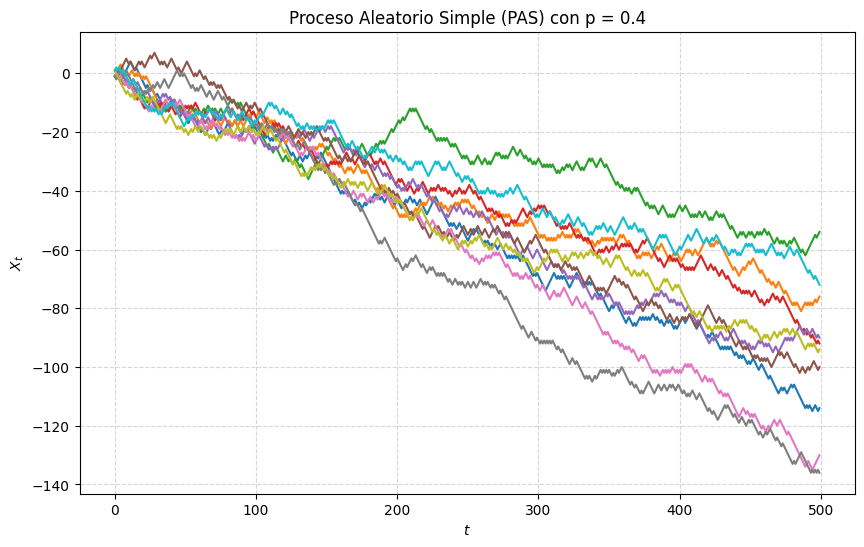

In [44]:
pas2 = simular_PAS(p=0.4, n=500, reps=10)
graficar_PAS(pas2, "Proceso Aleatorio Simple (PAS) con p = 0.4")

## Visualización 2: diferentes trayectorias del PAS (con media y desviación típica teóricas)

Escribir código para crear las imágenes de las diapositivas 30 ($p=0.5$), 31 ($p=0.75$), 32 ($p=0.95$) del tema 1.

Para el sombreado de las imágenes, que tiene amplitud $\pm$ 1 o 2 veces la desviación típica, busca en internet/LLM qué función de matplotlib te permite hacerlo.

---

Crearemos una nueva función para graficar un PAS junto a la media y las bandas de la desviación típica teóricas. Para ello usaremos la función

`plt.fill_between`: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.fill_between.html

Sabemos que la media teórica se calcula como
$$μ(n)=(2p-1)n$$

Por otro lado sabemos que la varianza teórica se calcula como
$$Var[X_n]=4p(1-p)n$$

Luego, la desviación típica teórica será:
$$σ(n) = \sqrt{4p(1-p)n}$$

In [45]:
def graficar_PAS_con_bandas(pas, p, texto="Proceso Aleatorio Simple (PAS)"):
    reps, n = pas.shape
    t = np.arange(n)

    # Media teórica
    media = t * (2*p - 1)

    # Desviación típica teórica
    sigma = np.sqrt(4 * p * (1-p) * t)

    # Establecemos el tamaño de la figura
    plt.figure(figsize=(11.5, 6))

    # Bandas +-2σ y +-1σ
    plt.fill_between(
        t, media - 2*sigma, media + 2*sigma,
        color='lightgray', alpha=0.5, label=r'$\pm 2\sigma$'
    )
    plt.fill_between(
        t, media - sigma, media + sigma,
        color='gray', alpha=0.25, label=r'$\pm 1\sigma$'
    )

    # Trayectorias
    for i in range(reps):
        plt.plot(t, pas[i], linewidth=1.3, alpha=0.6)

    # Media teórica
    plt.plot(t, media, 'k--', linewidth=2, label='Media teórica')

    plt.title(texto, fontsize=20)
    plt.xlabel('t', fontsize=16)
    plt.ylabel(r'$X_t$', fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.show()

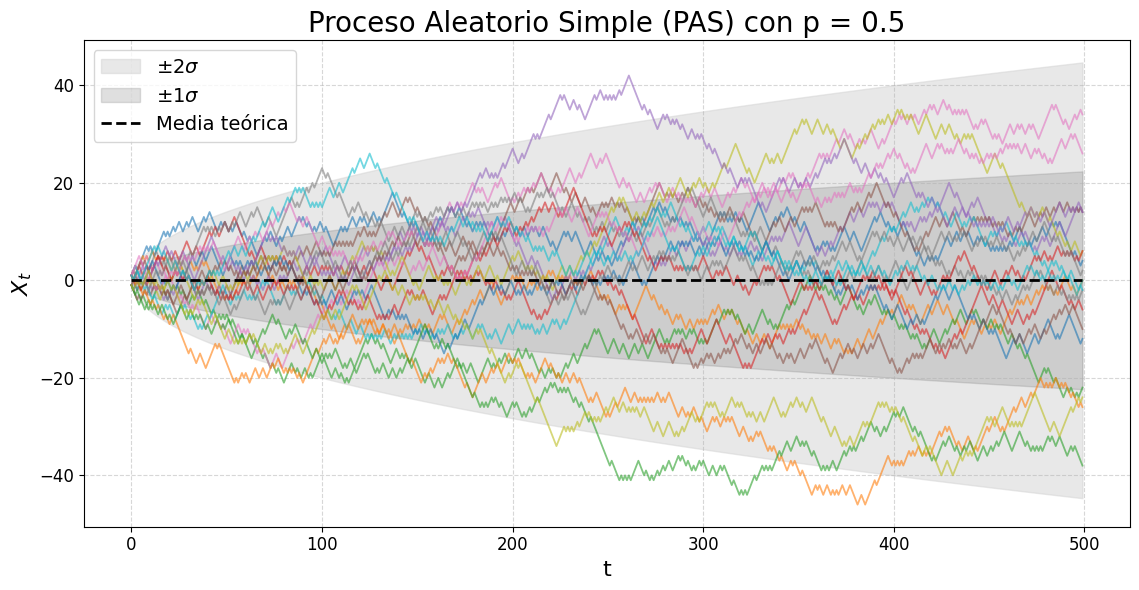

In [46]:
pas1 = simular_PAS(p=0.5, n=500, reps=20)
graficar_PAS_con_bandas(pas1, 0.5, "Proceso Aleatorio Simple (PAS) con p = 0.5")

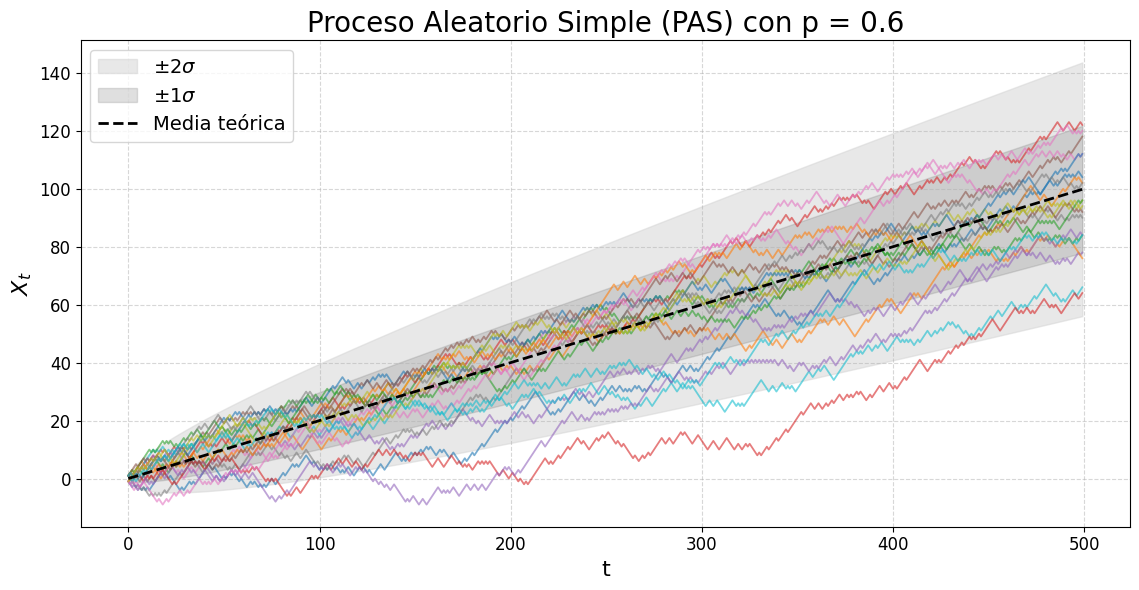

In [47]:
p = 0.6
pas2 = simular_PAS(p=p, n=500, reps=20)
graficar_PAS_con_bandas(pas2, p, "Proceso Aleatorio Simple (PAS) con p = 0.6")

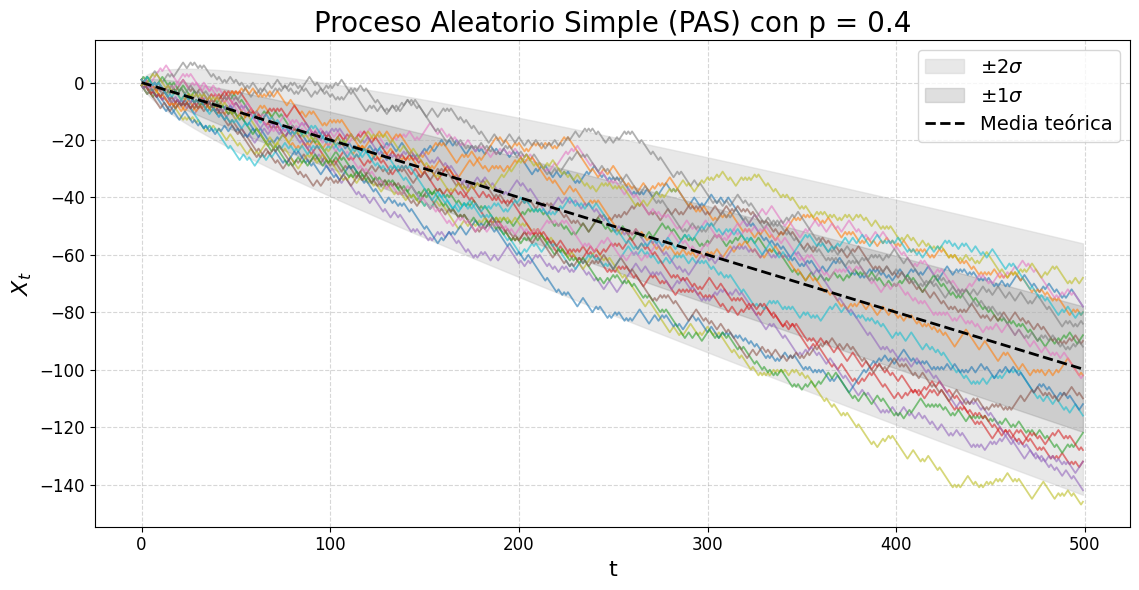

In [48]:
p = 0.4
pas3 = simular_PAS(p=p, n=500, reps=20)
graficar_PAS_con_bandas(pas3, p, "Proceso Aleatorio Simple (PAS) con p = 0.4")

## Visualización 3: visualización de la media empírica del PAS cuando aumentamos el número de trayectorias (junto con la media teórica)

Escribir código para crear la imagen de la diapositiva 35.

In [49]:
def graficar_media_empirica (n_trayectorias, p, n_pasos, texto="Media empirica"):
    t = np.arange(n_pasos)

    plt.figure(figsize=(10, 6))

    # Simulamos y graficamos cada PAS con distinto numero de trayectorias
    for reps in n_trayectorias:
        pas = simular_PAS(p=p, n=n_pasos, reps=reps)
        media_emp = np.mean(pas, axis=0)

        plt.plot(t, media_emp, linewidth=1.3, alpha=0.6, label=f'Nº Trayectorias = {reps}')

    media_teorica = t * (2*p - 1)
    plt.plot(t, media_teorica, 'k--', alpha = 0.5, linewidth=1.7, label='Media teórica')

    plt.title(texto, fontsize=20)
    plt.xlabel('t', fontsize=16)
    plt.ylabel(r'$X_t$', fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


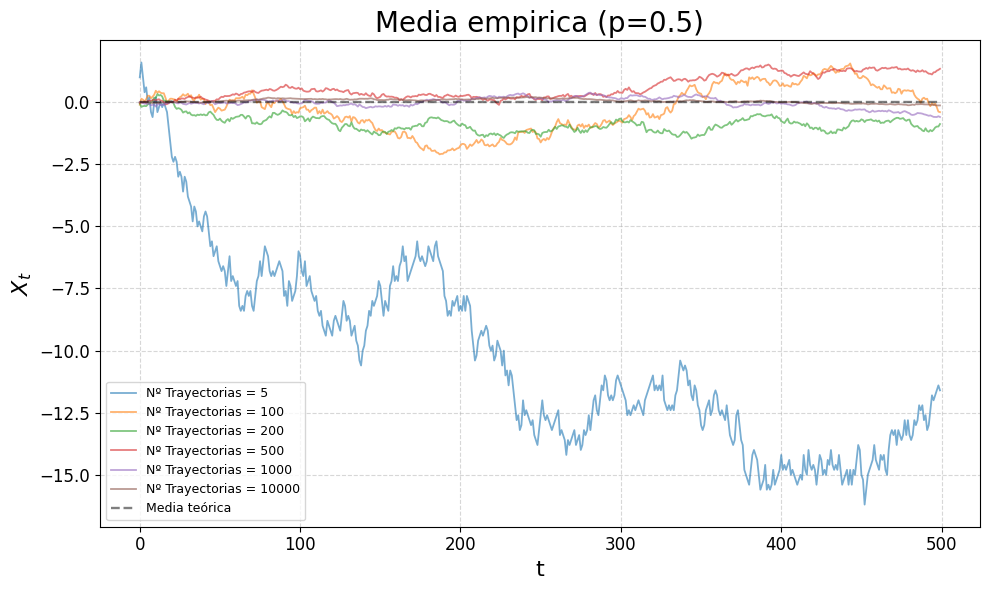

In [50]:
graficar_media_empirica(n_trayectorias=np.array([5, 100, 200, 500, 1000, 10000]), p=0.5, n_pasos=500, texto="Media empirica (p=0.5)")

Observamos que conforme aumentamos el número de trayectorias la media empírica se acerca cada vez más a la media teórica

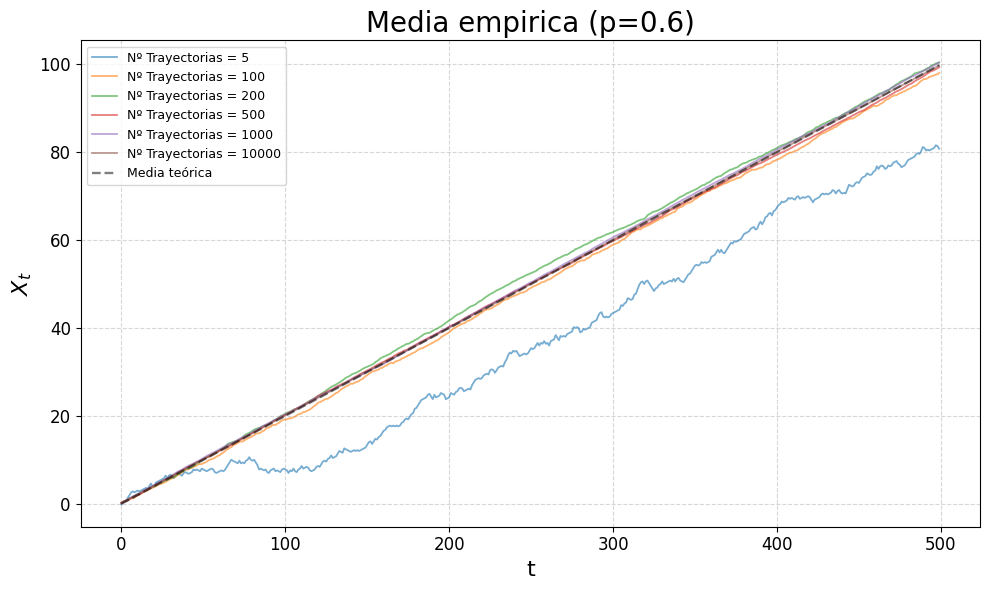

In [51]:
graficar_media_empirica(n_trayectorias=np.array([5, 100, 200, 500, 1000, 10000]), p=0.6, n_pasos=500, texto="Media empirica (p=0.6)")

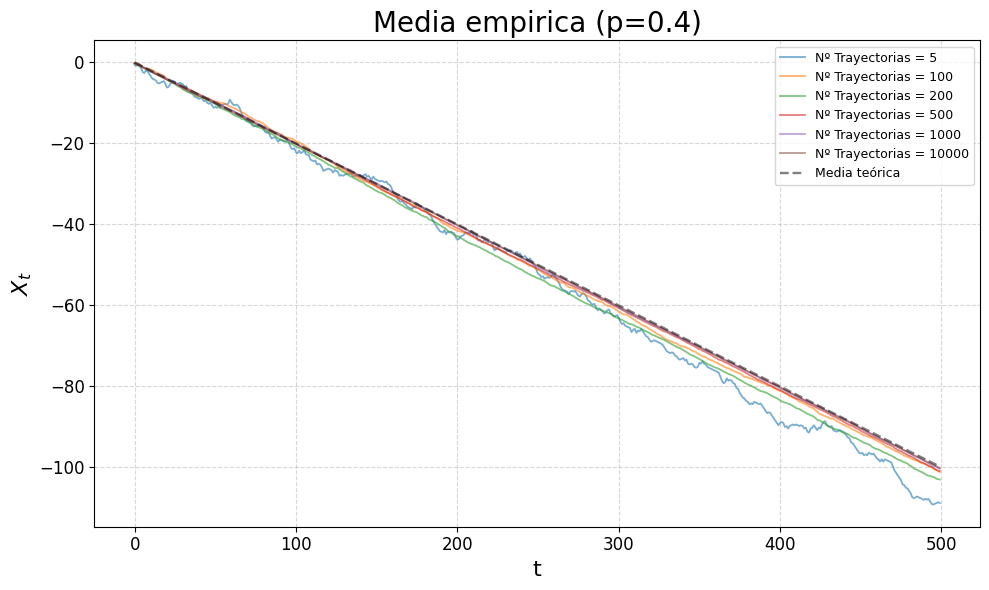

In [52]:
graficar_media_empirica(n_trayectorias=np.array([5, 100, 200, 500, 1000, 10000]), p=0.4, n_pasos=500, texto="Media empirica (p=0.4)")